# Assignment 06 - SVM

**Topics Covered:**
- Linear SVM
- Regularization (C): Balancing margin size vs misclassification
- Kernel Trick: Mapping data to higher dimensions

**Datasets:**
- (fruit_data_with_colors.txt)

**Student Name:** Raghad Abdelhameed
---

**Instructions:**
- Complete the code where you're asked to. **Do not modify or remove any other code**.
- Answer all written questions in the Markdown cells


In [1]:
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

### Use the following function to plot the classification regions

In [3]:
def plot_class_regions_for_classifier(clf, X, y, X_test=None, y_test=None, title=None, target_names = None, plot_decision_regions = True):

    numClasses = np.amax(y) + 1
    color_list_light = ['#FFFFAA', '#EFEFEF', '#AAFFAA', '#AAAAFF']
    color_list_bold = ['#EEEE00', '#000000', '#00CC00', '#0000CC']
    cmap_light = ListedColormap(color_list_light[0:numClasses])
    cmap_bold  = ListedColormap(color_list_bold[0:numClasses])

    h = 0.03
    k = 0.5
    x_plot_adjust = 0.1
    y_plot_adjust = 0.1
    plot_symbol_size = 50

    x_min = X[:, 0].min()
    x_max = X[:, 0].max()
    y_min = X[:, 1].min()
    y_max = X[:, 1].max()
    x2, y2 = np.meshgrid(np.arange(x_min-k, x_max+k, h), np.arange(y_min-k, y_max+k, h))
    # np.c_ Translates slice objects to concatenation along the second axis
    # e.g. np.c_[np.array([[1,2,3]]), 0, 0, np.array([[4,5,6]])]
    # ravel() Returns a contiguous flattened array.
    # x = np.array([[1, 2, 3], [4, 5, 6]])
    # np.ravel(x) = [1 2 3 4 5 6]
    P = clf.predict(np.c_[x2.ravel(), y2.ravel()])
    P = P.reshape(x2.shape)
    plt.figure()
    if plot_decision_regions:
        plt.contourf(x2, y2, P, cmap=cmap_light, alpha = 0.8)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, s=plot_symbol_size, edgecolor = 'black')
    plt.xlim(x_min - x_plot_adjust, x_max + x_plot_adjust)
    plt.ylim(y_min - y_plot_adjust, y_max + y_plot_adjust)

    if (X_test is not None):
        plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cmap_bold, s=plot_symbol_size, marker='^', edgecolor = 'black')
        train_score = clf.score(X, y)
        test_score  = clf.score(X_test, y_test)
        title = title + "\nTrain score = {:.2f}, Test score = {:.2f}".format(train_score, test_score)

    if (target_names is not None):
        legend_handles = []
        for i in range(0, len(target_names)):
            patch = mpatches.Patch(color=color_list_bold[i], label=target_names[i])
            legend_handles.append(patch)
        plt.legend(loc=0, handles=legend_handles)

    if (title is not None):
        plt.title(title)
    plt.show()

### Use the following dataset in questions 1, 2, and 3.

In [4]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples = 100, n_features=2,
                                n_redundant=0, n_informative=2,
                                n_clusters_per_class=1, flip_y = 0.1,
                                class_sep = 0.5, random_state=0)

#### Question 1
Split the data into training and testing datasets (use random_state=0 and 25% of the data for testing)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size:  {X_test.shape[0]} samples')

Training set size: 75 samples
Testing set size:  25 samples


#### Question 2
1. Train an SVM classifier using linear kernel.
2. Plot the classification regions using the training dataset.

Training accuracy: 0.8000
Testing  accuracy: 0.7600


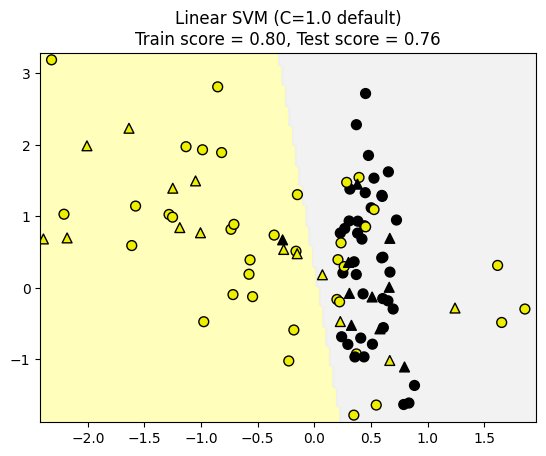

In [7]:
from sklearn.svm import SVC

# 1. Train SVM with linear kernel (default C=1.0)
clf_linear = SVC(kernel='linear', random_state=0)
clf_linear.fit(X_train, y_train)

print(f'Training accuracy: {clf_linear.score(X_train, y_train):.4f}')
print(f'Testing  accuracy: {clf_linear.score(X_test,  y_test):.4f}')

# 2. Plot classification regions
plot_class_regions_for_classifier(
    clf_linear, X_train, y_train,
    X_test, y_test,
    title='Linear SVM (C=1.0 default)'
)

#### Question 3
1. Train an SVM classifier using linear kernel with C=0.0001.
2. Train another SVM classifier using linear kernel with C=95
3. Plot the classification regions for both cases using the training dataset.
4. Comment on the results.

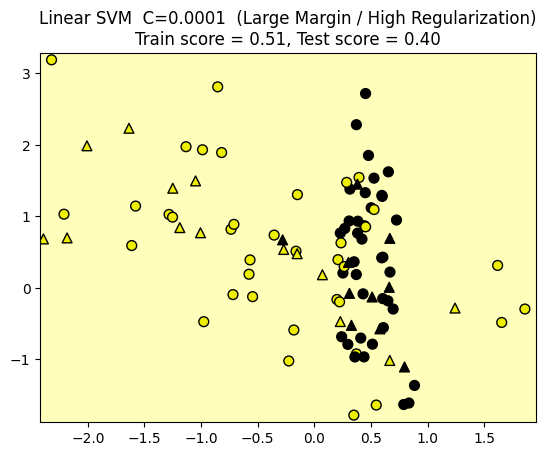

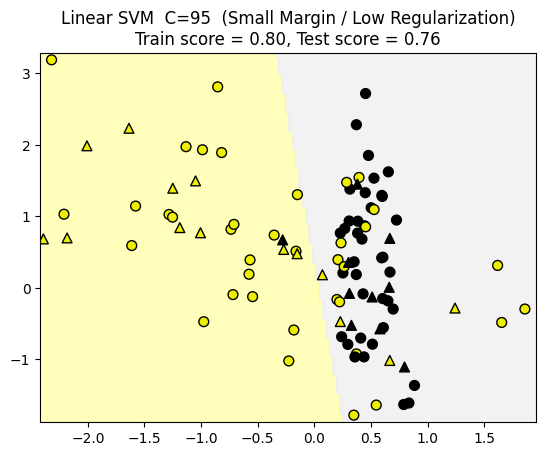

In [8]:
# 1. Linear SVM with C=0.0001 (very small => large margin, many misclassifications allowed)
clf_small_C = SVC(kernel='linear', C=0.0001, random_state=0)
clf_small_C.fit(X_train, y_train)

# 2. Linear SVM with C=95 (very large => small margin, tries hard to classify all points correctly)
clf_large_C = SVC(kernel='linear', C=95, random_state=0)
clf_large_C.fit(X_train, y_train)

# 3. Plot both
plot_class_regions_for_classifier(
    clf_small_C, X_train, y_train,
    X_test, y_test,
    title='Linear SVM  C=0.0001  (Large Margin / High Regularization)'
)

plot_class_regions_for_classifier(
    clf_large_C, X_train, y_train,
    X_test, y_test,
    title='Linear SVM  C=95  (Small Margin / Low Regularization)'
)

**Comment on Results (Q3):**

- **C = 0.0001 (very small):** The regularization is very strong, so the SVM prioritizes a **wide margin** even at the cost of more misclassifications. The decision boundary is simpler and may under-fit the training data.
- **C = 95 (very large):** The regularization is very weak, so the SVM tries to correctly classify **every training point**, resulting in a narrower margin. This can lead to over-fitting on training data and potentially lower generalization on unseen data.
- In general, the ideal C balances these two extremes and is found via cross-validation.

### Use the fruits dataset in questions 4, 5, 6.

In [9]:
import pandas as pd
fruits = pd.read_table('fruit_data_with_colors.txt')
feature_names_fruits = ['height', 'width', 'mass', 'color_score']

#### Question 4
1. Split the data by columns into X_fruits and y_fruits where X_fruits is the data records and y_fruits is the labels.
2. Using only the **'height'** and **'width'** features, split the data into training and testing using random_state=0, and 25% of the data for testing.
3. Using **sklearn LinearSVC**, train a linear svm

In [10]:
from sklearn.svm import LinearSVC

# 1. Split into features and labels
X_fruits = fruits[feature_names_fruits]   # all 4 feature columns
y_fruits = fruits['fruit_label']           # label column


In [13]:
# 2. Use only height & width, then split train/test
X_fruits_2d = fruits[['height', 'width']]

X_train_fruits, X_test_fruits, y_train_fruits, y_test_fruits = train_test_split(
    X_fruits_2d, y_fruits, test_size=0.25, random_state=0
)

print(f'Training samples: {X_train_fruits.shape[0]}')
print(f'Testing  samples: {X_test_fruits.shape[0]}')

Training samples: 44
Testing  samples: 15


In [14]:
# 3. Train LinearSVC
clf_fruits = LinearSVC(random_state=0, max_iter=5000)
clf_fruits.fit(X_train_fruits, y_train_fruits)

print(f'\nTraining accuracy: {clf_fruits.score(X_train_fruits, y_train_fruits):.4f}')
print(f'Testing  accuracy: {clf_fruits.score(X_test_fruits,  y_test_fruits):.4f}')


Training accuracy: 0.7500
Testing  accuracy: 0.4667


#### Question 5
For the previous model from question 4.
1. How many SVM models have been trained? and Why?
2. Print the models' coefficients and intercepts.

In [15]:
# Answer to Q5-1: Number of models
num_classes  = len(np.unique(y_train_fruits))   # 4 fruit classes
num_models   = clf_fruits.coef_.shape[0]         # number of decision boundaries

print(f'Number of classes : {num_classes}')
print(f'Number of SVM models trained: {num_models}')
print()
print('Explanation:')
print('  LinearSVC uses the One-vs-Rest (OvR) strategy for multi-class classification.')
print('  For K classes, K binary classifiers are trained — one per class.')
print(f'  Here K = {num_classes}, so {num_models} SVMs were trained (one per fruit type).')

Number of classes : 4
Number of SVM models trained: 4

Explanation:
  LinearSVC uses the One-vs-Rest (OvR) strategy for multi-class classification.
  For K classes, K binary classifiers are trained — one per class.
  Here K = 4, so 4 SVMs were trained (one per fruit type).


In [16]:
# Answer to Q5-2: Coefficients and intercepts
print('\n--- Coefficients (one row per model) ---')
print(f'  Shape: {clf_fruits.coef_.shape}  (n_models x n_features)')
for i, (coef, intercept) in enumerate(zip(clf_fruits.coef_, clf_fruits.intercept_)):
    print(f'  Model {i+1}: coef={coef}, intercept={intercept:.4f}')


--- Coefficients (one row per model) ---
  Shape: (4, 2)  (n_models x n_features)
  Model 1: coef=[-0.28037302  0.47594355], intercept=-1.5127
  Model 2: coef=[-1.10758759  0.78948855], intercept=0.7873
  Model 3: coef=[-0.03929154  0.21300773], intercept=-1.6799
  Model 4: coef=[ 1.01073208 -1.26248135], intercept=0.3759


#### Question 6
Plot the classification boundary of each svm on a scatter plot of the training data.
(plot it any way you can)

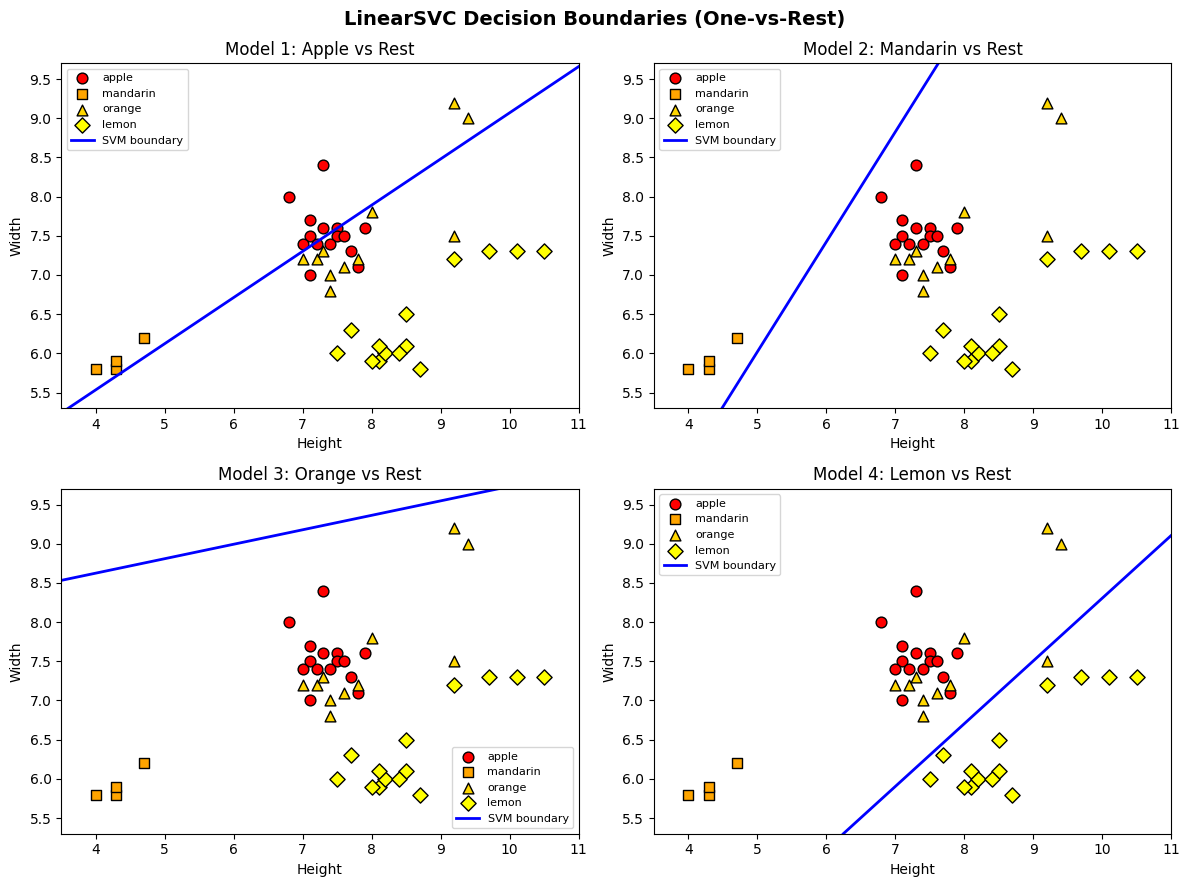

In [17]:
fruit_names = {1: 'apple', 2: 'mandarin', 3: 'orange', 4: 'lemon'}
colors_map  = {1: 'red', 2: 'orange', 3: 'gold', 4: 'yellow'}
marker_map  = {1: 'o', 2: 's', 3: '^', 4: 'D'}

X_tr = X_train_fruits.values
y_tr = y_train_fruits.values

# Axis range
x_min, x_max = X_tr[:, 0].min() - 0.5, X_tr[:, 0].max() + 0.5
y_min, y_max = X_tr[:, 1].min() - 0.5, X_tr[:, 1].max() + 0.5
x_vals = np.linspace(y_min, y_max, 200)   # width values for boundary line

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for idx, (coef, intercept, ax) in enumerate(zip(clf_fruits.coef_, clf_fruits.intercept_, axes)):
    class_label = idx + 1
    # Scatter all training points
    for lbl, name in fruit_names.items():
        mask = (y_tr == lbl)
        ax.scatter(
            X_tr[mask, 0], X_tr[mask, 1],
            label=name, edgecolor='black', s=60,
            color=colors_map[lbl], marker=marker_map[lbl]
        )

    # Decision boundary: coef[0]*height + coef[1]*width + intercept = 0
    # => height = -(coef[1]*width + intercept) / coef[0]
    if abs(coef[0]) > 1e-10:
        boundary_heights = -(coef[1] * x_vals + intercept) / coef[0]
        ax.plot(boundary_heights, x_vals, 'b-', lw=2, label=f'SVM boundary')

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Height')
    ax.set_ylabel('Width')
    ax.set_title(f'Model {class_label}: {fruit_names[class_label].capitalize()} vs Rest')
    ax.legend(fontsize=8)

plt.suptitle('LinearSVC Decision Boundaries (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 Use the breast cancer dataset in question 7, 8, and9.

In [18]:
from sklearn.datasets import load_breast_cancer
(X_cancer, y_cancer) = load_breast_cancer(return_X_y = True)

#### Question 7
1. Split the dataset into training and testing datasets, use random_state = 0, and 25% of the data for testing.
2. Use GridSearchCV to find the best C value for and SVM classifier with rbf kernel and print the best C value. *use:*  
```python
parameters = {'kernel' : ('poly', 'rbf'), 'C':[0.001, 0.01, 0.1, 0.5, 1, 10]}
```
3. Print the best parameters resulted from your grid search.

In [19]:
from sklearn.model_selection import GridSearchCV

# 1. Train/test split
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.25, random_state=0
)

# 2. GridSearchCV
parameters = {'kernel': ('poly', 'rbf'), 'C': [0.001, 0.01, 0.1, 0.5, 1, 10]}
svc = SVC(random_state=0)
grid_search = GridSearchCV(svc, parameters, cv=5, scoring='accuracy')
grid_search.fit(X_train_cancer, y_train_cancer)

GridSearchCV(cv=5, estimator=SVC(random_state=0),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1, 10],
                         'kernel': ('poly', 'rbf')},
             scoring='accuracy')

In [20]:
# 3. Print best parameters
print('Best Parameters:', grid_search.best_params_)
print(f'Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}')

Best Parameters: {'C': 10, 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.9154


#### Question 8
Train an SVM model using the best parameters resulted from question 7, then calculate and print the training and testing accuracy.

In [21]:
best_params = grid_search.best_params_

# Train with best parameters
clf_cancer = SVC(**best_params, random_state=0)
clf_cancer.fit(X_train_cancer, y_train_cancer)

train_acc = clf_cancer.score(X_train_cancer, y_train_cancer)
test_acc  = clf_cancer.score(X_test_cancer,  y_test_cancer)

print(f'Best Parameters Used: {best_params}')
print(f'Training Accuracy : {train_acc:.4f}')
print(f'Testing  Accuracy : {test_acc:.4f}')

Best Parameters Used: {'C': 10, 'kernel': 'rbf'}
Training Accuracy : 0.9155
Testing  Accuracy : 0.9371


#### Question 9
Improve the previous results from question 8.

**Hint:** Don't change the model, instead, make some preprocessing on the data.

In [22]:
from sklearn.preprocessing import StandardScaler

# Preprocessing: StandardScaler normalizes features to zero mean and unit variance
# SVMs are sensitive to feature scale, so normalization greatly improves performance.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cancer)  # fit on train only
X_test_scaled  = scaler.transform(X_test_cancer)       # apply same transform to test

In [23]:
# Re-run GridSearchCV on scaled data
grid_search_scaled = GridSearchCV(SVC(random_state=0), parameters, cv=5, scoring='accuracy')
grid_search_scaled.fit(X_train_scaled, y_train_cancer)

best_params_scaled = grid_search_scaled.best_params_
print(f'Best Parameters (scaled): {best_params_scaled}')
print(f'Best CV Accuracy  (scaled): {grid_search_scaled.best_score_:.4f}')

Best Parameters (scaled): {'C': 1, 'kernel': 'rbf'}
Best CV Accuracy  (scaled): 0.9741


In [24]:
# Train final model with best params on scaled data
clf_scaled = SVC(**best_params_scaled, random_state=0)
clf_scaled.fit(X_train_scaled, y_train_cancer)

train_acc_scaled = clf_scaled.score(X_train_scaled, y_train_cancer)
test_acc_scaled  = clf_scaled.score(X_test_scaled,  y_test_cancer)

In [26]:

print(f'\n--- Before Scaling ---')
print(f'  Training Accuracy: {train_acc:.4f}  |  Testing Accuracy: {test_acc:.4f}')
print(f'--- After Scaling  ---')
print(f'  Training Accuracy: {train_acc_scaled:.4f}  |  Testing Accuracy: {test_acc_scaled:.4f}')
print('\nConclusion: StandardScaler significantly improves SVM accuracy because SVMs')
print('depend on distances between data points, which are distorted by different feature scales.')


--- Before Scaling ---
  Training Accuracy: 0.9155  |  Testing Accuracy: 0.9371
--- After Scaling  ---
  Training Accuracy: 0.9859  |  Testing Accuracy: 0.9650

Conclusion: StandardScaler significantly improves SVM accuracy because SVMs
depend on distances between data points, which are distorted by different feature scales.
